# Fine-tuning de un VLM ligero para clasificación de posiciones de natación artística

## Contexto

Este cuaderno entrena un modelo de visión-lenguaje **pequeño y de código abierto** con fine-tuning supervisado para clasificar las cinco posiciones reglamentarias de natación artística:

| Código | Nombre completo |
|--------|------------------|
| BP6    | Double Leg Vertical |
| BP8    | Fishtail |
| BP14c  | Bent Knee Vertical |
| BP14d  | Bent Knee Surface Arch Position |
| BP17   | Knight |

## Modelo elegido: BLIP base (`Salesforce/blip-image-captioning-base`)

| Característica | BLIP-2 (descartado) | **BLIP base (este cuaderno)** |
|---|---|---|
| Tamaño en disco | ~3 GB | **~990 MB** |
| Parámetros | ~2.7 B | **~224 M** |
| LLM acoplado | OPT-2.7B | Ninguno (decoder BERT) |
| Cuantización necesaria | Sí (8-bit) | **No** |
| VRAM mínima | ~8 GB | **~2-3 GB** |

BLIP combina un **encoder visual ViT-B/16** con un **text decoder BERT** para generación condicionada a la imagen.  
Se aplica **LoRA** sobre las capas de atención del decoder, actualizando solo ~0.5 % de los parámetros.

## Comparativa con otros enfoques del proyecto

| Enfoque | Modelo | Parámetros | Fine-tuning |
|---------|--------|------------|-------------|
| CNN transfer learning | EfficientNetB3 | ~12 M | Completo |
| Zero-shot CLIP | CLIP ViT-B/32 | ~151 M | Ninguno |
| Coordenadas + ML clásico | Random Forest / SVM | — | Completo |
| Skills Anthropic | Claude Sonnet 4.5 | ~175 B (est.) | Ninguno |
| **Este cuaderno** | **BLIP base + LoRA** | **~224 M** | **LoRA (~1 M)** |

---
## 1. Importaciones y configuración global

In [1]:
import random
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import BlipProcessor, BlipForConditionalGeneration
from peft import LoraConfig, get_peft_model, TaskType

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [2]:
# ── Rutas ─────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('.')
DATA_DIR     = NOTEBOOK_DIR / '..' / 'Data'
CSV_PATH     = DATA_DIR / 'synchronized_swimming_aug.csv'
MODEL_SAVE   = NOTEBOOK_DIR / 'blip_lora_natacion'

# ── Modelo ────────────────────────────────────────────────────────────────────
MODEL_ID = 'Salesforce/blip-image-captioning-base'   # ~990 MB, ~224 M parámetros
PROMPT   = 'Question: What swimming body position is shown in this image? Answer:'

# ── Hiperparámetros ──────────────────────────────────────────────────────────
SEED           = 42
BATCH_SIZE     = 4
NUM_EPOCHS     = 5
LR             = 2e-4
MAX_NEW_TOKENS = 20
MAX_TEXT_LEN   = 64

# ── División del dataset ──────────────────────────────────────────────────────
VAL_RATIO  = 0.15
TEST_RATIO = 0.15

# ── LoRA ─────────────────────────────────────────────────────────────────────
LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05

# ── Reproducibilidad ─────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {props.name}  |  VRAM: {props.total_memory / 1e9:.1f} GB')

Dispositivo: cpu


---
## 2. Carga y exploración del dataset

Se carga `synchronized_swimming_aug.csv` (~6 575 imágenes, 5 clases).  
El CSV usa rutas relativas a la carpeta `Data/`.

In [3]:
def cargar_dataset(csv_path: Path, base_dir: Path) -> pd.DataFrame:
    """Carga el CSV, resuelve rutas absolutas y filtra imágenes inexistentes."""
    csv_path = Path(csv_path)
    base_dir = Path(base_dir).resolve()

    if not csv_path.exists():
        raise FileNotFoundError(f'CSV no encontrado: {csv_path.resolve()}')

    df = pd.read_csv(csv_path)
    df['abs_path'] = df['filepath'].apply(
        lambda p: (base_dir / Path(p.replace('\\', '/'))).resolve()
    )

    mask       = df['abs_path'].apply(lambda p: p.exists())
    n_total    = len(df)
    df         = df[mask].reset_index(drop=True)
    n_omitidas = n_total - len(df)

    if n_omitidas > 0:
        print(f'Advertencia: {n_omitidas} entradas sin archivo válido omitidas.')
    if df.empty:
        raise RuntimeError('No se encontraron imágenes válidas. Verifica DATA_DIR.')

    print(f'Dataset cargado: {len(df):,} imágenes · {df["label"].nunique()} clases\n')
    return df


df = cargar_dataset(CSV_PATH, DATA_DIR)
print('Distribución de clases:')
print(df['label'].value_counts().to_string())
print()
df.head()

Dataset cargado: 6,575 imágenes · 5 clases

Distribución de clases:
label
Knight                             1575
Fishtail                           1475
Bent Knee Vertical                 1300
Double Leg Vertical                1250
Bent Knee Surface Arch Position     975



,filepath,label,abs_path
0,Augmented\Bent Knee Surface Arch Position\IMG_...,Bent Knee Surface Arch Position,C:\paula\OTROS\TFG_repo\Data\Augmented\Bent Kn...
1,Augmented\Bent Knee Surface Arch Position\IMG_...,Bent Knee Surface Arch Position,C:\paula\OTROS\TFG_repo\Data\Augmented\Bent Kn...
2,Augmented\Bent Knee Surface Arch Position\IMG_...,Bent Knee Surface Arch Position,C:\paula\OTROS\TFG_repo\Data\Augmented\Bent Kn...
3,Augmented\Bent Knee Surface Arch Position\IMG_...,Bent Knee Surface Arch Position,C:\paula\OTROS\TFG_repo\Data\Augmented\Bent Kn...
4,Augmented\Bent Knee Surface Arch Position\IMG_...,Bent Knee Surface Arch Position,C:\paula\OTROS\TFG_repo\Data\Augmented\Bent Kn...


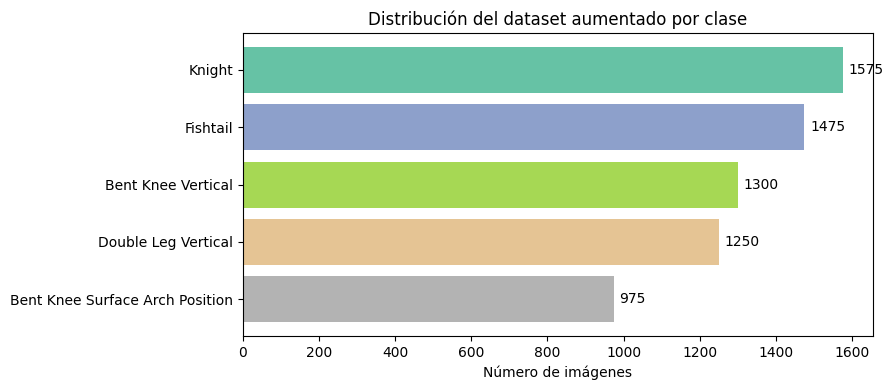

In [4]:
# Distribución de clases
conteos = df['label'].value_counts()
colores = plt.cm.Set2(np.linspace(0, 1, len(conteos)))

fig, ax = plt.subplots(figsize=(9, 4))
barras  = ax.barh(conteos.index, conteos.values, color=colores)
ax.bar_label(barras, padding=4, fontsize=10)
ax.set_xlabel('Número de imágenes')
ax.set_title('Distribución del dataset aumentado por clase')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

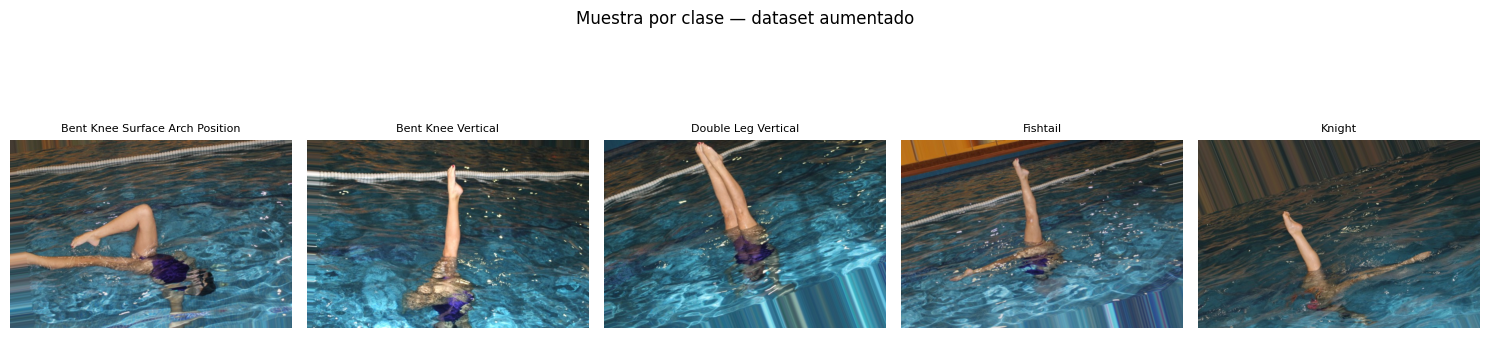

In [5]:
# Una imagen de muestra por clase
CLASES = sorted(df['label'].unique())

fig, axes = plt.subplots(1, len(CLASES), figsize=(15, 4))
for ax, cls in zip(axes, CLASES):
    muestra = df[df['label'] == cls].sample(1, random_state=SEED).iloc[0]
    img     = Image.open(muestra['abs_path']).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls, fontsize=8)
    ax.axis('off')
plt.suptitle('Muestra por clase — dataset aumentado', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

---
## 3. División del dataset

Partición estratificada por clase: **70 % entrenamiento · 15 % validación · 15 % test**.

In [6]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

df_trainval, df_test = train_test_split(
    df, test_size=TEST_RATIO, stratify=df['label_enc'], random_state=SEED
)
df_train, df_val = train_test_split(
    df_trainval,
    test_size=VAL_RATIO / (1.0 - TEST_RATIO),
    stratify=df_trainval['label_enc'],
    random_state=SEED,
)

for nombre, subdf in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    print(f'{nombre:>5}: {len(subdf):>5} imágenes')
    for cls, n in subdf['label'].value_counts().items():
        print(f'         {cls}: {n}')
    print()

Train:  4601 imágenes
         Knight: 1102
         Fishtail: 1032
         Bent Knee Vertical: 910
         Double Leg Vertical: 874
         Bent Knee Surface Arch Position: 683

  Val:   987 imágenes
         Knight: 236
         Fishtail: 222
         Bent Knee Vertical: 195
         Double Leg Vertical: 188
         Bent Knee Surface Arch Position: 146

 Test:   987 imágenes
         Knight: 237
         Fishtail: 221
         Bent Knee Vertical: 195
         Double Leg Vertical: 188
         Bent Knee Surface Arch Position: 146



---
## 4. Dataset personalizado y DataLoaders

La tarea se formula como **generación condicionada**:
- **Train** — entrada: `"Question: … Answer: [CLASE]"` + imagen; las pérdidas solo se calculan sobre los tokens de la clase.
- **Eval** — entrada: `"Question: … Answer:"` + imagen; se genera la clase libremente.

In [7]:
class NatacionDataset(Dataset):
    """
    Dataset de natación artística para fine-tuning de BLIP base.

    Args:
        df:         DataFrame con columnas 'abs_path' y 'label'.
        processor:  BlipProcessor.
        prompt:     Texto de la pregunta.
        max_length: Longitud máxima de tokenización.
        mode:       'train' o 'eval'.
    """

    def __init__(self, df, processor, prompt=PROMPT, max_length=MAX_TEXT_LEN, mode='train'):
        self.df         = df.reset_index(drop=True)
        self.processor  = processor
        self.prompt     = prompt
        self.max_length = max_length
        self.mode       = mode

        prompt_ids      = processor.tokenizer(prompt, return_tensors='pt').input_ids
        self.prompt_len = prompt_ids.shape[-1]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fila  = self.df.iloc[idx]
        imagen = Image.open(fila['abs_path']).convert('RGB')
        label  = fila['label']

        texto = f'{self.prompt} {label}' if self.mode == 'train' else self.prompt

        encoding = self.processor(
            images=imagen,
            text=texto,
            return_tensors='pt',
            padding='max_length',
            max_length=self.max_length,
            truncation=True,
        )

        item = {
            'pixel_values':   encoding['pixel_values'].squeeze(0),
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label_text':     label,
        }

        if self.mode == 'train':
            labels = encoding['input_ids'].clone()
            labels[0, :self.prompt_len] = -100   # no supervisar el prompt
            pad_id = self.processor.tokenizer.pad_token_id
            if pad_id is not None:
                labels[labels == pad_id] = -100
            item['labels'] = labels.squeeze(0)

        return item

In [8]:
print(f'Cargando procesador: {MODEL_ID} ...')
processor = BlipProcessor.from_pretrained(MODEL_ID)
print('Procesador listo.\n')


def collate_fn(batch):
    label_texts = [b.pop('label_text') for b in batch]
    collated    = {k: torch.stack([b[k] for b in batch]) for k in batch[0]}
    collated['label_text'] = label_texts
    return collated


ds_train = NatacionDataset(df_train, processor, mode='train')
ds_val   = NatacionDataset(df_val,   processor, mode='eval')
ds_test  = NatacionDataset(df_test,  processor, mode='eval')

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, collate_fn=collate_fn)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_fn)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_fn)

print(f'Batches — Train: {len(dl_train)} · Val: {len(dl_val)} · Test: {len(dl_test)}')

Cargando procesador: Salesforce/blip-image-captioning-base ...


The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Procesador listo.

Batches — Train: 1151 · Val: 247 · Test: 247


---
## 5. Carga del modelo y configuración LoRA

**BLIP base** (~224 M parámetros, ~990 MB) se carga directamente en GPU/CPU sin cuantización.

**LoRA** adapta las proyecciones `query` y `value` del text decoder BERT con rango `r=16`:

$$W' = W + \Delta W = W + B \cdot A \quad (r \ll d)$$

Solo ~1 M de parámetros son entrenables (~0.5 % del total).

In [9]:
print(f'Cargando modelo: {MODEL_ID}\n')

# float32 siempre: BLIP base cabe en RAM/VRAM sin float16,
# y evita dtype mismatch entre el modelo base y los adaptadores LoRA.
model = BlipForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32,
)
model = model.to(DEVICE)
print('Modelo base cargado.\n')

# LoRA sobre el text decoder (capas BERT de atención: query y value)
# TaskType.FEATURE_EXTRACTION → PeftModel base, que NO sobreescribe generate().
# Así, model.generate() delega directamente al generate() de BlipForConditionalGeneration,
# que sí sabe manejar pixel_values. Con CAUSAL_LM el generate() de PEFT intercepta
# la llamada y falla porque no espera pixel_values.
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias='none',
    task_type=TaskType.FEATURE_EXTRACTION,
    target_modules=['query', 'value'],
)

model = get_peft_model(model, lora_config)

params_total       = sum(p.numel() for p in model.parameters())
params_entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros totales:       {params_total:>12,}')
print(f'Parámetros entrenables:   {params_entrenables:>12,}  ({100 * params_entrenables / params_total:.2f} %)')

Cargando modelo: Salesforce/blip-image-captioning-base



Loading weights: 100%|██████████| 473/473 [00:01<00:00, 297.79it/s, Materializing param=vision_model.post_layernorm.weight]                                       
The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decod

Modelo base cargado.

Parámetros totales:        248,624,248
Parámetros entrenables:      1,179,648  (0.47 %)


---
## 6. Entrenamiento (fine-tuning supervisado)

In [10]:
def normalizar_prediccion(pred: str, clases: list) -> str:
    """Mapea texto libre generado al nombre de clase más cercano."""
    pred_norm = pred.strip().lower()

    for cls in clases:
        if cls.lower() == pred_norm:
            return cls
    for cls in clases:
        if cls.lower() in pred_norm or pred_norm in cls.lower():
            return cls

    mejor_cls, mejor_n = clases[0], 0
    for cls in clases:
        n = sum(w in pred_norm for w in cls.lower().split())
        if n > mejor_n:
            mejor_n, mejor_cls = n, cls
    return mejor_cls


def entrenar_epoca(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch in tqdm(dataloader, desc='  Entrenando', leave=False):
        _ = batch.pop('label_text')
        pixel_values   = batch['pixel_values'].to(device)
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model.base_model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )

        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += outputs.loss.item()

    return total_loss / len(dataloader)


@torch.no_grad()
def evaluar(model, dataloader, device, clases, desc='Evaluando'):
    model.eval()
    y_true, y_pred = [], []

    for batch in tqdm(dataloader, desc=f'  {desc}', leave=False):
        label_texts    = batch.pop('label_text')
        pixel_values   = batch['pixel_values'].to(device)
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        generated = model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=MAX_NEW_TOKENS,
        )
        predicciones = processor.batch_decode(generated, skip_special_tokens=True)
        y_true.extend(label_texts)
        y_pred.extend([normalizar_prediccion(p, clases) for p in predicciones])

    return accuracy_score(y_true, y_pred), y_true, y_pred

In [14]:
# Subconjunto mini para prueba rápida (10 imgs/clase = 50 en total)
# Para entrenar con todo el dataset, sustituir dl_train_mini por dl_train
N_POR_CLASE_MINI = 50
N_VAL_MINI = 30

df_train_mini = pd.concat([
    df_train.loc[df_train['label'] == cls, ['filepath', 'label', 'abs_path']]
    .sample(min(N_POR_CLASE_MINI, int((df_train['label'] == cls).sum())), random_state=SEED)
    for cls in CLASES
]).reset_index(drop=True)

df_val_mini = df_val.sample(min(N_VAL_MINI, len(df_val)), random_state=SEED).reset_index(drop=True)

ds_train_mini = NatacionDataset(df_train_mini, processor, mode='train')
dl_train_mini = DataLoader(
    ds_train_mini, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, collate_fn=collate_fn
)

ds_val_mini = NatacionDataset(df_val_mini, processor, mode='eval')
dl_val_mini = DataLoader(
    ds_val_mini, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_fn
)

print(f'Mini-train: {len(df_train_mini)} imágenes · {len(dl_train_mini)} batches')
print(f'Mini-val:   {len(df_val_mini)} imágenes · {len(dl_val_mini)} batches')

# Optimizador y scheduler
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=0.01,
)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# Bucle de entrenamiento
MODEL_SAVE.mkdir(parents=True, exist_ok=True)
ruta_mejor   = MODEL_SAVE / 'mejor_checkpoint'
historial    = {'train_loss': [], 'val_acc': []}
mejor_val_acc = 0.0

print(f'\nInicio del fine-tuning · {NUM_EPOCHS} épocas · dispositivo: {DEVICE}')
print(f'Train: {len(df_train_mini)} imgs (mini)  ·  Val: {len(df_val_mini)} imgs (mini)\n')
print(f'{"Época":>5} | {"Train Loss":>10} | {"Val Acc":>8}')
print('-' * 32)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss = entrenar_epoca(model, dl_train_mini, optimizer, DEVICE)
    val_acc, _, _ = evaluar(model, dl_val_mini, DEVICE, CLASES, desc='Validando')

    historial['train_loss'].append(tr_loss)
    historial['val_acc'].append(val_acc)
    scheduler.step()

    marca = '<- mejor' if val_acc > mejor_val_acc else ''
    print(f'{epoch:>5} | {tr_loss:>10.4f} | {val_acc:>8.4f}  {marca}')

    if val_acc > mejor_val_acc:
        mejor_val_acc = val_acc
        model.save_pretrained(str(ruta_mejor))

print(f'\nFine-tuning completado. Mejor val_acc: {mejor_val_acc:.4f}')
print('Tip: cambia dl_train_mini -> dl_train y dl_val_mini -> dl_val para usar los datasets completos.')

Mini-train: 250 imágenes · 63 batches
Mini-val:   30 imágenes · 8 batches

Inicio del fine-tuning · 5 épocas · dispositivo: cpu
Train: 250 imgs (mini)  ·  Val: 30 imgs (mini)

Época | Train Loss |  Val Acc
--------------------------------


  Entrenando:   0%|          | 0/63 [00:00<?, ?it/s]

  Validando:  88%|████████▊ | 7/8 [00:30<00:04,  4.37s/it]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


    1 |     0.0338 |   0.1333  <- mejor


  Validando:  88%|████████▊ | 7/8 [00:29<00:04,  4.21s/it]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


...

    3 |     0.0004 |   0.1333  


  Validando:  88%|████████▊ | 7/8 [00:27<00:04,  4.23s/it]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


    4 |     0.0003 |   0.1333  


  Validando:  88%|████████▊ | 7/8 [00:26<00:03,  3.77s/it]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
                                                          

    5 |     0.0002 |   0.1333  

Fine-tuning completado. Mejor val_acc: 0.1333
Tip: cambia dl_train_mini -> dl_train y dl_val_mini -> dl_val para usar los datasets completos.


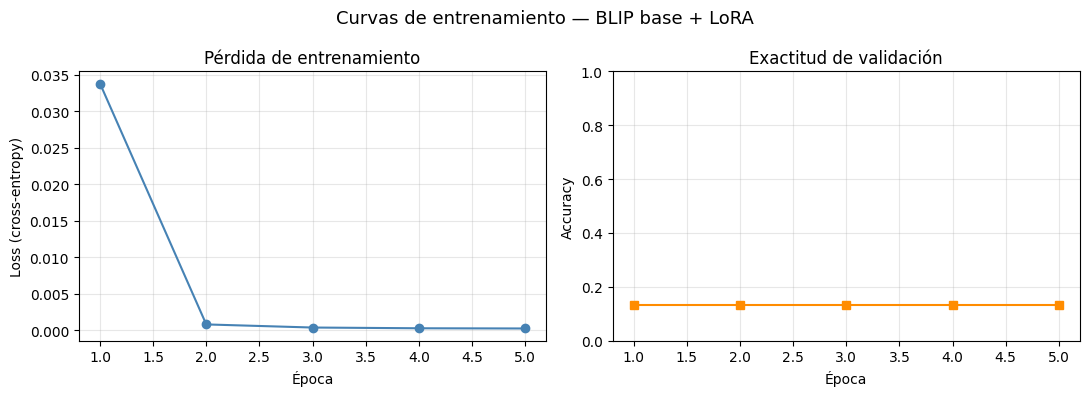

In [15]:
# Curvas de entrenamiento
epocas = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epocas, historial['train_loss'], marker='o', color='steelblue')
ax1.set_title('Pérdida de entrenamiento')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss (cross-entropy)')
ax1.grid(True, alpha=0.3)

ax2.plot(epocas, historial['val_acc'], marker='s', color='darkorange')
ax2.set_title('Exactitud de validación')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de entrenamiento — BLIP base + LoRA', fontsize=13)
plt.tight_layout()
plt.savefig(MODEL_SAVE / 'curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Evaluación sobre el conjunto de test

In [16]:
print('Evaluando con el mejor checkpoint...\n')
test_acc, y_true, y_pred = evaluar(model, dl_test, DEVICE, CLASES, desc='Test')
print(f'Test Accuracy: {test_acc:.4f}  ({test_acc * 100:.2f} %)')

Evaluando con el mejor checkpoint...



  Test: 100%|█████████▉| 246/247 [16:57<00:02,  2.57s/it]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
                                                         

Test Accuracy: 0.1479  (14.79 %)


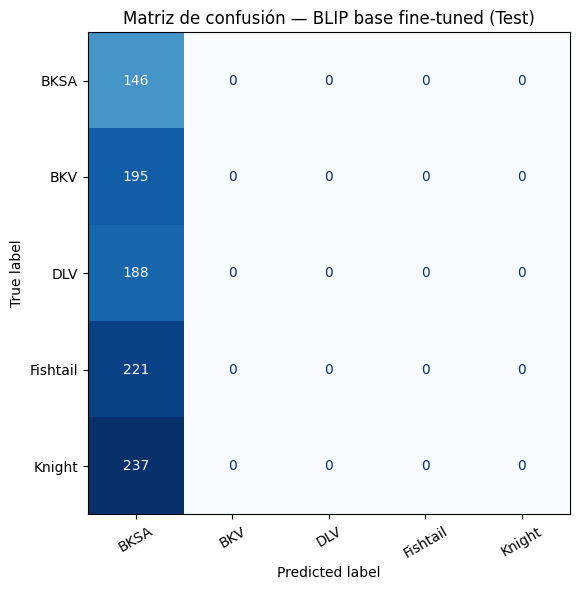

In [17]:
ABREV = {
    'Double Leg Vertical':              'DLV',
    'Fishtail':                         'Fishtail',
    'Bent Knee Vertical':               'BKV',
    'Bent Knee Surface Arch Position':  'BKSA',
    'Knight':                           'Knight',
}
display_labels = [ABREV.get(c, c) for c in CLASES]

cm = confusion_matrix(y_true, y_pred, labels=CLASES)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=display_labels).plot(
    ax=ax, colorbar=False, cmap='Blues', xticks_rotation=30
)
ax.set_title('Matriz de confusión — BLIP base fine-tuned (Test)')
plt.tight_layout()
plt.savefig(MODEL_SAVE / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
print('Informe de clasificación (Test):\n')
print(classification_report(y_true, y_pred, labels=CLASES, target_names=display_labels, digits=4))

Informe de clasificación (Test):

              precision    recall  f1-score   support

        BKSA     0.1479    1.0000    0.2577       146
         BKV     0.0000    0.0000    0.0000       195
         DLV     0.0000    0.0000    0.0000       188
    Fishtail     0.0000    0.0000    0.0000       221
      Knight     0.0000    0.0000    0.0000       237

    accuracy                         0.1479       987
   macro avg     0.0296    0.2000    0.0515       987
weighted avg     0.0219    0.1479    0.0381       987



---
## 8. Predicciones de muestra

Borde **verde** = correcto · Borde **rojo** = error.

KeyError: 'label'

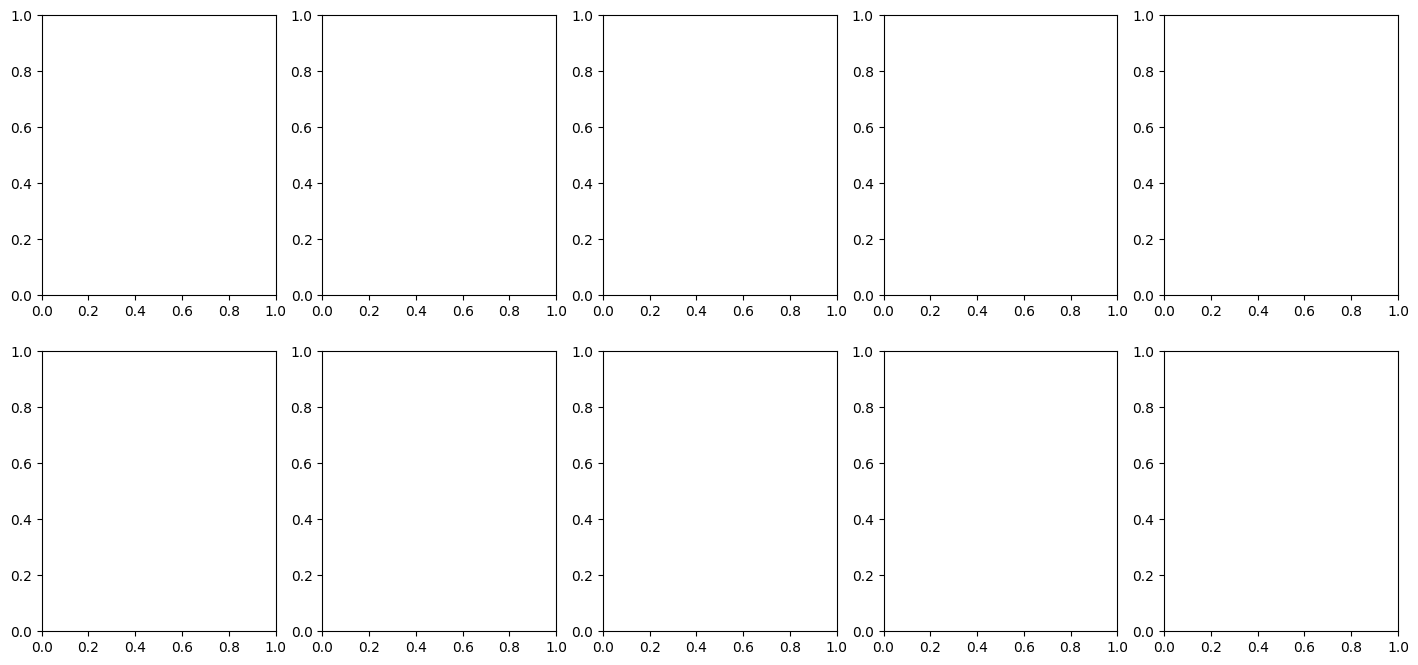

In [19]:
@torch.no_grad()
def mostrar_predicciones(df_split, model, processor, device, clases, n_por_clase=2, seed=SEED):
    model.eval()
    muestras = (
        df_split
        .groupby('label', group_keys=False)
        .apply(lambda g: g.sample(min(n_por_clase, len(g)), random_state=seed))
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(n_por_clase, len(clases), figsize=(3.5 * len(clases), 4 * n_por_clase))
    if n_por_clase == 1:
        axes = axes.reshape(1, -1)

    for col, cls in enumerate(clases):
        filas_cls = muestras[muestras['label'] == cls].reset_index(drop=True)
        for row in range(n_por_clase):
            ax = axes[row, col]
            if row >= len(filas_cls):
                ax.axis('off')
                continue
            fila = filas_cls.iloc[row]
            img  = Image.open(fila['abs_path']).convert('RGB')

            enc = processor(
                images=img, text=PROMPT, return_tensors='pt',
                padding='max_length', max_length=MAX_TEXT_LEN, truncation=True,
            ).to(device)

            gen      = model.generate(
                pixel_values=enc['pixel_values'],
                input_ids=enc['input_ids'],
                attention_mask=enc['attention_mask'],
                max_new_tokens=MAX_NEW_TOKENS,
            )
            pred_raw = processor.decode(gen[0], skip_special_tokens=True).strip()
            pred     = normalizar_prediccion(pred_raw, clases)
            correcto = pred == cls
            color    = 'green' if correcto else 'red'

            ax.imshow(img)
            ax.axis('off')
            ax.set_title(f'Real: {ABREV.get(cls, cls)}\nPred: {ABREV.get(pred, pred)}', fontsize=9, color=color)
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)

    fig.legend(
        handles=[mpatches.Patch(color='green', label='Correcto'),
                 mpatches.Patch(color='red',   label='Incorrecto')],
        loc='lower right', fontsize=11,
    )
    plt.suptitle('Predicciones de muestra — BLIP base fine-tuned (Test)', fontsize=13)
    plt.tight_layout()
    plt.savefig(MODEL_SAVE / 'predicciones_muestra.png', dpi=150, bbox_inches='tight')
    plt.show()


mostrar_predicciones(df_test, model, processor, DEVICE, CLASES, n_por_clase=2)

---
## 9. Guardado del modelo fine-tuned

Solo se guardan los **pesos LoRA** (unos pocos MB). Para inferencia, se carga el modelo base desde HuggingFace y se fusiona el adaptador.

In [ ]:
ruta_final = MODEL_SAVE / 'adaptador_lora_final'
model.save_pretrained(str(ruta_final))
processor.save_pretrained(str(ruta_final))

print(f'Adaptador LoRA guardado en: {ruta_final.resolve()}')
print()
print('Para cargar en otra sesión:')
print(f"""
from transformers import BlipProcessor, BlipForConditionalGeneration
from peft import PeftModel

base  = BlipForConditionalGeneration.from_pretrained('{MODEL_ID}')
model = PeftModel.from_pretrained(base, 'blip_lora_natacion/adaptador_lora_final')
proc  = BlipProcessor.from_pretrained('blip_lora_natacion/adaptador_lora_final')
""")